# Customer Segmentation with K-Means

This notebook uses **K-Means clustering** to segment customers based on their behaviour so that marketing and sales teams can target different groups with more relevant campaigns instead of treating all customers the same.


## 1. Business Problem

The business has many customers but a limited marketing budget. Sending the same promotion to everyone is inefficient and often ineffective.

We want to **discover data-driven customer segments** using K-Means clustering so that we can:

- Understand different customer profiles (e.g. “high spend & loyal”, “occasional low spenders”).
- Prioritise high-value or high-potential groups.
- Design different campaigns for different segments.

This is an **unsupervised learning** problem: we do not have labels; we want to uncover natural groupings in the data.


## 2. Setup and Imports

In [1]:
import os

# Limit the number of math "helper threads" to avoid the KMeans warning on Windows + MKL
os.environ["OMP_NUM_THREADS"] = "2"


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


## 3. Load Data



In [5]:
mall = pd.read_csv("https://talktoroh.com/s/app_users_week03.csv")

mall.head()

,Unnamed: 0,age,sessions_per_week,avg_session_duration
0,0,22,3,13
1,1,25,3,17
2,2,26,1,21
3,3,19,2,17
4,4,23,3,14


## 4. Data Understanding

We first look at the structure of the dataset and basic statistics to understand what features are available and whether there are missing values or obvious issues.


In [7]:
mall.info()

mall.describe(include="all")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Unnamed: 0            300 non-null    int64
 1   age                   300 non-null    int64
 2   sessions_per_week     300 non-null    int64
 3   avg_session_duration  300 non-null    int64
dtypes: int64(4)
memory usage: 9.5 KB


,Unnamed: 0,age,sessions_per_week,avg_session_duration
count,300.000000,300.000000,300.000000,300.000000
mean,149.500000,38.560000,2.596667,22.733333
std,86.746758,12.923226,1.501612,7.304799
min,0.000000,18.000000,1.000000,8.000000
25%,74.750000,27.000000,1.000000,16.000000
50%,149.500000,38.000000,2.000000,23.000000
75%,224.250000,49.000000,3.000000,28.000000
max,299.000000,64.000000,6.000000,44.000000


## 5. Feature Selection and Scaling

For clustering we focus on numerical behavioural features. In the classic mall dataset these are usually:

- Annual income
- Spending score

We standardise them so that both features have mean 0 and standard deviation 1. This ensures that K-Means (which uses distance) is not dominated by a feature just because it has larger units.


In [9]:
mall.columns


Index(['Unnamed: 0', 'age', 'sessions_per_week', 'avg_session_duration'], dtype='object')

In [11]:
# Use the actual column names from your data
feature_cols = ["age", "sessions_per_week", "avg_session_duration"]

# Build X from those columns
X = mall[feature_cols].copy()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X.head(), X_scaled[:5]


(   age  sessions_per_week  avg_session_duration
 0   22                  3                    13
 1   25                  3                    17
 2   26                  1                    21
 3   19                  2                    17
 4   23                  3                    14,
 array([[-1.28355485,  0.26904904, -1.3346837 ],
        [-1.0510268 ,  0.26904904, -0.78618355],
        [-0.97351745, -1.06507842, -0.2376834 ],
        [-1.5160829 , -0.39801469, -0.78618355],
        [-1.2060455 ,  0.26904904, -1.19755866]]))

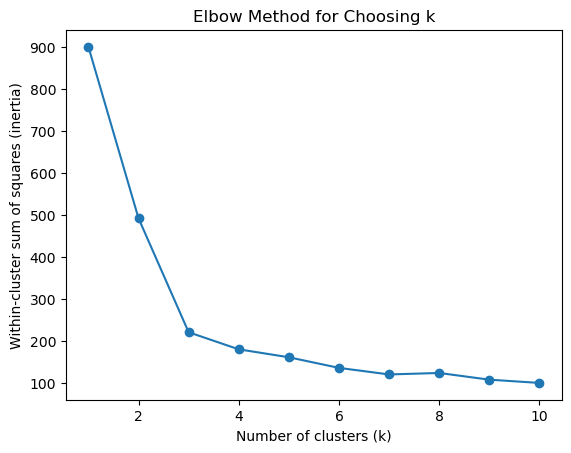

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wss = []                  # within-cluster sum of squares
k_values = range(1, 11)   # try k = 1 to 10

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=2025)
    kmeans.fit(X_scaled)
    wss.append(kmeans.inertia_)

plt.figure()
plt.plot(k_values, wss, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Within-cluster sum of squares (inertia)")
plt.title("Elbow Method for Choosing k")
plt.show()


In [17]:
k = 3  # change to 4 etc. if your elbow suggests that

kmeans = KMeans(n_clusters=k, random_state=2025)
kmeans.fit(X_scaled)

# Attach cluster labels back onto the original data
mall["cluster"] = kmeans.labels_

mall.head()


,Unnamed: 0,age,sessions_per_week,avg_session_duration,cluster
0,0,22,3,13,0
1,1,25,3,17,0
2,2,26,1,21,0
3,3,19,2,17,0
4,4,23,3,14,0


In [19]:
feature_cols = ["age", "sessions_per_week", "avg_session_duration"]

cluster_profile = mall.groupby("cluster")[feature_cols].mean().round(1)
cluster_profile


,age,sessions_per_week,avg_session_duration
cluster,,,
0,24.2,2.0,14.5
1,53.8,1.5,24.9
2,37.8,4.3,28.9


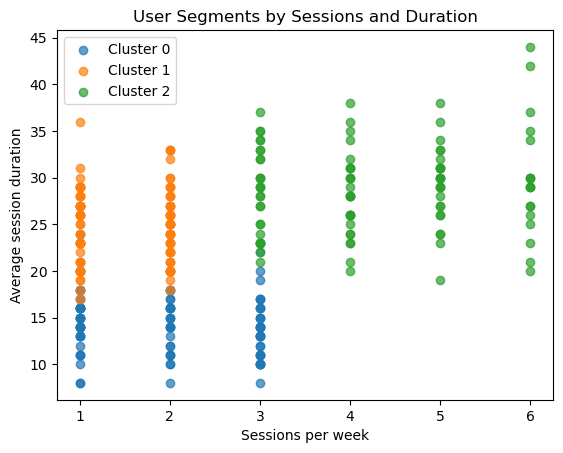

In [32]:
plt.figure()
for c in sorted(mall["cluster"].unique()):
    subset = mall[mall["cluster"] == c]
    plt.scatter(
        subset["sessions_per_week"],
        subset["avg_session_duration"],
        label=f"Cluster {c}",
        alpha=0.7
    )

plt.xlabel("Sessions per week")
plt.ylabel("Average session duration")
plt.title("User Segments by Sessions and Duration")
plt.legend()

plt.savefig("images/kmeans_sessions_duration_clusters.png", dpi=150, bbox_inches="tight")
plt.show()


In [34]:
feature_cols = ["age", "sessions_per_week", "avg_session_duration"]

cluster_profile = mall.groupby("cluster")[feature_cols].mean().round(1)
cluster_profile


,age,sessions_per_week,avg_session_duration
cluster,,,
0,24.2,2.0,14.5
1,53.8,1.5,24.9
2,37.8,4.3,28.9


## 9. Conclusions and Recommendations

Based on the cluster profiles and scatter plot, we can interpret the segments as:

- **Cluster 0 – Light, quick users**  
  Fewer sessions per week and shorter session durations. These users dip in and out briefly.  
  **Action:** Use simple nudges and low-effort campaigns (e.g. email or in-app reminders) to increase visit frequency and gradually deepen engagement.

- **Cluster 1 – Occasional but deep users**  
  1–2 sessions per week but relatively long sessions when they do log in.  
  **Action:** Promote features that reward their deep engagement (e.g. advanced content, long-form features, or personalised recommendations) and encourage them to come slightly more often.

- **Cluster 2 – Heavy, highly engaged users**  
  More sessions per week and long session durations. These are power users and likely to be the most valuable segment.  
  **Action:** Focus on retention – loyalty rewards, beta access to new features, and gathering feedback from them to improve the product. They can also be advocates for referrals or word-of-mouth growth.

Overall, K-Means clustering lets us move from a one-size-fits-all strategy to a **segmented engagement strategy**, where different user groups receive different treatments based on how frequently and how deeply they use the app.


In [36]:
import os
os.makedirs("images", exist_ok=True)


In [38]:
plt.savefig("images/kmeans_sessions_duration_clusters.png", dpi=150, bbox_inches="tight")
plt.show()


<Figure size 640x480 with 0 Axes>